# A/B Test

## Data Cleaning

In [5]:
import pandas as pd

ab_data = pd.read_csv('ab_data.csv')
countries = pd.read_csv('countries.csv')

df = ab_data.merge(countries, on="user_id", how="left")

df.head()

,user_id,timestamp,group,landing_page,converted,country
0,851104,11:48.6,control,old_page,0,US
1,804228,01:45.2,control,old_page,0,US
2,661590,55:06.2,treatment,new_page,0,US
3,853541,28:03.1,treatment,new_page,0,US
4,864975,52:26.2,control,old_page,1,US


In [6]:
df = df[((df['group'] == 'treatment') & (df['landing_page'] == 'new_page')) |
        ((df['group'] == 'control') & (df['landing_page'] == 'old_page'))]

In [7]:
df.head(33)

,user_id,timestamp,group,landing_page,converted,country
0,851104,11:48.6,control,old_page,0,US
1,804228,01:45.2,control,old_page,0,US
2,661590,55:06.2,treatment,new_page,0,US
3,853541,28:03.1,treatment,new_page,0,US
4,864975,52:26.2,control,old_page,1,US
5,936923,20:49.1,control,old_page,0,US
6,679687,26:46.9,treatment,new_page,1,CA
7,719014,48:29.5,control,old_page,0,US
8,817355,58:09.0,treatment,new_page,1,UK
9,839785,11:06.6,treatment,new_page,1,CA


In [8]:
df.to_csv("ab_test_ecommerce_analysis_ready.csv", index=False)

## STEP 1: LOAD THE DATA

In [77]:
import pandas as pd
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

# ============================================================
# STEP 1: LOAD THE DATA
# ============================================================
print("=" * 60)
print("STEP 1: LOADING THE DATA")
print("=" * 60)


# Clean column names (remove spaces)
df.columns = df.columns.str.strip()

print(f"Shape of dataset: {df.shape}")
print(f"Columns: {list(df.columns)}")

STEP 1: LOADING THE DATA
Shape of dataset: (290589, 10)
Columns: ['user_id', 'timestamp', 'group', 'landing_page', 'converted', 'country', 'time_seconds', 'minute_bucket', 'sequence_split', 'time_split']


## STEP 2: FIRST LOOK AT THE DATA

In [17]:
# ============================================================
# STEP 2: FIRST LOOK AT THE DATA
# ============================================================
print("=" * 60)
print("STEP 2: FIRST LOOK AT THE DATA (first 5 rows)")
print("=" * 60)

print(df.head())

STEP 2: FIRST LOOK AT THE DATA (first 5 rows)
   user_id timestamp      group landing_page  converted country
0   851104   11:48.6    control     old_page          0      US
1   804228   01:45.2    control     old_page          0      US
2   661590   55:06.2  treatment     new_page          0      US
3   853541   28:03.1  treatment     new_page          0      US
4   864975   52:26.2    control     old_page          1      US


## STEP 3: CHECK FOR MISSING VALUES

In [19]:
# ============================================================
# STEP 3: CHECK FOR MISSING VALUES
# ============================================================
print("=" * 60)
print("STEP 3: CHECK FOR MISSING VALUES")
print("=" * 60)

print(df.isnull().sum())

STEP 3: CHECK FOR MISSING VALUES
user_id         0
timestamp       0
group           0
landing_page    0
converted       0
country         0
dtype: int64


## STEP 4: CHECK FOR DUPLICATE USERS

In [21]:
# ============================================================
# STEP 4: CHECK FOR DUPLICATE USERS
# ============================================================
print("=" * 60)
print("STEP 4: CHECK FOR DUPLICATE USERS")
print("=" * 60)

total_rows = len(df)
unique_users = df['user_id'].nunique()
duplicate_rows = total_rows - unique_users

print(f"Total rows       : {total_rows}")
print(f"Unique user_ids  : {unique_users}")
print(f"Duplicate rows   : {duplicate_rows}")

STEP 4: CHECK FOR DUPLICATE USERS
Total rows       : 290589
Unique user_ids  : 290585
Duplicate rows   : 4


## STEP 5: SHOW THE DUPLICATED USERS

In [23]:
# ============================================================
# STEP 5: SHOW THE DUPLICATED USERS
# ============================================================
print("=" * 60)
print("STEP 5: SHOW THE DUPLICATED USERS")
print("=" * 60)

# Find user_ids that appear more than once
dup_ids = df[df.duplicated('user_id', keep=False)]['user_id'].unique()
print(f"User IDs with duplicates: {dup_ids}")
print()
print(df[df['user_id'].isin(dup_ids)].sort_values('user_id'))

STEP 5: SHOW THE DUPLICATED USERS
User IDs with duplicates: [773192 759899]

        user_id timestamp      group landing_page  converted country
250001   759899   07:36.1  treatment     new_page          0      US
250002   759899   07:36.1  treatment     new_page          0      US
294479   759899   20:29.0  treatment     new_page          0      US
294480   759899   20:29.0  treatment     new_page          0      US
1899     773192   37:58.8  treatment     new_page          0      US
2893     773192   55:59.6  treatment     new_page          0      US


## STEP 6: REMOVE DUPLICATES — KEEP FIRST OCCURRENCE PER USER

In [25]:
# ============================================================
# STEP 6: REMOVE DUPLICATES — KEEP FIRST OCCURRENCE PER USER
# ============================================================
print("=" * 60)
print("STEP 6: REMOVE DUPLICATES")
print("=" * 60)

df_clean = df.drop_duplicates(subset='user_id', keep='first').copy()

print(f"Rows before cleaning : {len(df)}")
print(f"Rows after cleaning  : {len(df_clean)}")
print(f"Rows removed         : {len(df) - len(df_clean)}")

STEP 6: REMOVE DUPLICATES
Rows before cleaning : 290589
Rows after cleaning  : 290585
Rows removed         : 4


## STEP 7: CHECK IF ANY USER IS IN BOTH GROUPS

In [31]:
df_clean = df.drop_duplicates(subset='user_id', keep='first').copy()

# ============================================================
# STEP 7: CHECK IF ANY USER IS IN BOTH GROUPS
# ============================================================
print("=" * 60)
print("STEP 7: CHECK IF ANY USER IS IN BOTH GROUPS")
print("=" * 60)

# Count how many groups each user appears in
groups_per_user = df_clean.groupby('user_id')['group'].nunique()

# Users in more than 1 group = problem
users_in_both = groups_per_user[groups_per_user > 1]

print(f"Users appearing in BOTH control and treatment: {len(users_in_both)}")

if len(users_in_both) == 0:
    print("✅ No user is in both groups. Experiment is clean!")
else:
    print("⚠️  Problem found! These users are in both groups:")
    print(users_in_both)

STEP 7: CHECK IF ANY USER IS IN BOTH GROUPS
Users appearing in BOTH control and treatment: 0
✅ No user is in both groups. Experiment is clean!


## STEP 8: CHECK RANDOMIZATION BALANCE (group sizes)

In [33]:
# ============================================================
# STEP 8: CHECK RANDOMIZATION BALANCE (group sizes)
# ============================================================
print("=" * 60)
print("STEP 8: CHECK RANDOMIZATION BALANCE")
print("=" * 60)

group_counts = df_clean['group'].value_counts()
print(group_counts)
print()

treatment_share = group_counts['treatment'] / group_counts.sum() * 100
print(f"Treatment share: {treatment_share:.3f}%")
print("(Ideal is 50%. Anything close to 50% is good.)")

STEP 8: CHECK RANDOMIZATION BALANCE
group
treatment    145311
control      145274
Name: count, dtype: int64

Treatment share: 50.006%
(Ideal is 50%. Anything close to 50% is good.)


## STEP 9: STATISTICAL TEST FOR BALANCE (is 50/50 split real?)

In [35]:
# ============================================================
# STEP 9: STATISTICAL TEST FOR BALANCE (is 50/50 split real?)
# ============================================================
print("=" * 60)
print("STEP 9: STATISTICAL TEST FOR BALANCE")
print("=" * 60)

n_control   = (df_clean['group'] == 'control').sum()
n_treatment = (df_clean['group'] == 'treatment').sum()
n_total     = n_control + n_treatment

# Z-test: is the split significantly different from 50/50?
p_expected = 0.5
p_observed = n_treatment / n_total
z = (p_observed - p_expected) / np.sqrt(p_expected * (1 - p_expected) / n_total)
p_val = 2 * (1 - stats.norm.cdf(abs(z)))

print(f"Control users   : {n_control}")
print(f"Treatment users : {n_treatment}")
print(f"Z-statistic     : {z:.4f}")
print(f"P-value         : {p_val:.4f}")
print()
if p_val > 0.05:
    print("✅ Balance is fine. The split is not significantly different from 50/50.")
else:
    print("⚠️  Imbalance detected! The split is significantly different from 50/50.")

STEP 9: STATISTICAL TEST FOR BALANCE
Control users   : 145274
Treatment users : 145311
Z-statistic     : 0.0686
P-value         : 0.9453

✅ Balance is fine. The split is not significantly different from 50/50.


## STEP 10: OVERALL CONVERSION RATE PER GROUP


In [37]:
# ============================================================
# STEP 10: OVERALL CONVERSION RATE PER GROUP
# ============================================================
print("=" * 60)
print("STEP 10: OVERALL CONVERSION RATE PER GROUP")
print("=" * 60)

summary = df_clean.groupby('group')['converted'].agg(
    users='count',
    conversions='sum'
)
summary['conversion_rate_%'] = (summary['conversions'] / summary['users'] * 100).round(4)

print(summary)

STEP 10: OVERALL CONVERSION RATE PER GROUP
            users  conversions  conversion_rate_%
group                                            
control    145274        17489            12.0386
treatment  145311        17264            11.8807


## STEP 11: CALCULATE LIFT (how much better/worse is treatment?)


In [39]:
# ============================================================
# STEP 11: CALCULATE LIFT (how much better/worse is treatment?)
# ============================================================
print("=" * 60)
print("STEP 11: CALCULATE LIFT")
print("=" * 60)

p_control   = df_clean[df_clean['group'] == 'control']['converted'].mean()
p_treatment = df_clean[df_clean['group'] == 'treatment']['converted'].mean()

absolute_lift = p_treatment - p_control
relative_lift = (absolute_lift / p_control) * 100

print(f"Control conversion rate   : {p_control*100:.4f}%")
print(f"Treatment conversion rate : {p_treatment*100:.4f}%")
print()
print(f"Absolute lift : {absolute_lift*100:.4f} percentage points")
print(f"Relative lift : {relative_lift:.4f}%")
print()
if absolute_lift > 0:
    print("📈 Treatment is BETTER than control.")
else:
    print("📉 Treatment is WORSE than control.")

STEP 11: CALCULATE LIFT
Control conversion rate   : 12.0386%
Treatment conversion rate : 11.8807%

Absolute lift : -0.1579 percentage points
Relative lift : -1.3117%

📉 Treatment is WORSE than control.


## STEP 12: Z-TEST FOR PROPORTIONS (main statistical test)

In [41]:
# ============================================================
# STEP 12: Z-TEST FOR PROPORTIONS (main statistical test)
# ============================================================
print("=" * 60)
print("STEP 12: Z-TEST FOR PROPORTIONS")
print("=" * 60)

# Get values needed for the test
n_c  = (df_clean['group'] == 'control').sum()       # control users
n_t  = (df_clean['group'] == 'treatment').sum()     # treatment users
x_c  = df_clean[df_clean['group'] == 'control']['converted'].sum()    # control conversions
x_t  = df_clean[df_clean['group'] == 'treatment']['converted'].sum()  # treatment conversions

p_c = x_c / n_c   # control rate
p_t = x_t / n_t   # treatment rate

# Pooled proportion (used in the z-test formula)
p_pool = (x_c + x_t) / (n_c + n_t)

# Standard error
se = np.sqrt(p_pool * (1 - p_pool) * (1/n_c + 1/n_t))

# Z-statistic
z = (p_t - p_c) / se

# Two-sided p-value
p_value = 2 * (1 - stats.norm.cdf(abs(z)))

print(f"Control   : {x_c} conversions out of {n_c} users")
print(f"Treatment : {x_t} conversions out of {n_t} users")
print()
print(f"Z-statistic : {z:.4f}")
print(f"P-value     : {p_value:.6f}")
print()
if p_value < 0.05:
    print("✅ SIGNIFICANT: We reject H0. The difference is real.")
else:
    print("❌ NOT SIGNIFICANT: We fail to reject H0. No proven difference.")

STEP 12: Z-TEST FOR PROPORTIONS
Control   : 17489 conversions out of 145274 users
Treatment : 17264 conversions out of 145311 users

Z-statistic : -1.3116
P-value     : 0.189653

❌ NOT SIGNIFICANT: We fail to reject H0. No proven difference.


## STEP 13: CONFIDENCE INTERVAL (95%)

In [43]:
p_c = df_clean[df_clean['group'] == 'control']['converted'].mean()
p_t = df_clean[df_clean['group'] == 'treatment']['converted'].mean()
n_c = (df_clean['group'] == 'control').sum()
n_t = (df_clean['group'] == 'treatment').sum()

# ============================================================
# STEP 13: CONFIDENCE INTERVAL (95%)
# ============================================================
print("=" * 60)
print("STEP 13: 95% CONFIDENCE INTERVAL FOR THE DIFFERENCE")
print("=" * 60)

# Standard error for the difference (unpooled, for CI)
se_diff = np.sqrt(p_c*(1-p_c)/n_c + p_t*(1-p_t)/n_t)

# 95% CI uses z = 1.96
z_critical = 1.96
diff = p_t - p_c
ci_lower = diff - z_critical * se_diff
ci_upper = diff + z_critical * se_diff

print(f"Difference (treatment - control) : {diff*100:.4f} pp")
print(f"95% Confidence Interval          : [{ci_lower*100:.4f} pp,  {ci_upper*100:.4f} pp]")
print()
print("Interpretation:")
print("  If the CI includes 0, the difference could be due to chance.")
print("  If the CI is entirely above 0, treatment is clearly better.")
print("  If the CI is entirely below 0, treatment is clearly worse.")
print()
if ci_lower > 0:
    print("✅ CI is entirely above 0 → Treatment is significantly better.")
elif ci_upper < 0:
    print("❌ CI is entirely below 0 → Treatment is significantly worse.")
else:
    print("⚠️  CI crosses 0 → No conclusive difference.")

STEP 13: 95% CONFIDENCE INTERVAL FOR THE DIFFERENCE
Difference (treatment - control) : -0.1579 pp
95% Confidence Interval          : [-0.3939 pp,  0.0781 pp]

Interpretation:
  If the CI includes 0, the difference could be due to chance.
  If the CI is entirely above 0, treatment is clearly better.
  If the CI is entirely below 0, treatment is clearly worse.

⚠️  CI crosses 0 → No conclusive difference.


## STEP 14: BUSINESS IMPACT AT SCALE

In [45]:
p_c = df_clean[df_clean['group'] == 'control']['converted'].mean()
p_t = df_clean[df_clean['group'] == 'treatment']['converted'].mean()
absolute_lift = p_t - p_c

# ============================================================
# STEP 14: BUSINESS IMPACT AT SCALE
# ============================================================
print("=" * 60)
print("STEP 14: BUSINESS IMPACT AT SCALE")
print("=" * 60)

aov = 75  # Average Order Value in dollars (assumed)

for users in [100_000, 1_000_000]:
    incremental_conversions = absolute_lift * users
    revenue_impact = incremental_conversions * aov
    print(f"At {users:>10,} users:")
    print(f"  Incremental conversions : {incremental_conversions:+.1f}")
    print(f"  Revenue impact (AOV $75): ${revenue_impact:+,.0f}")
    print()

STEP 14: BUSINESS IMPACT AT SCALE
At    100,000 users:
  Incremental conversions : -157.9
  Revenue impact (AOV $75): $-11,843

At  1,000,000 users:
  Incremental conversions : -1579.1
  Revenue impact (AOV $75): $-118,429



## STEP 15: CONVERSION RATE BY COUNTRY


In [47]:
# ============================================================
# STEP 15: CONVERSION RATE BY COUNTRY
# ============================================================
print("=" * 60)
print("STEP 15: CONVERSION RATE BY COUNTRY")
print("=" * 60)

country_summary = df_clean.groupby(['country', 'group'])['converted'].agg(
    users='count',
    conversions='sum'
)
country_summary['rate_%'] = (country_summary['conversions'] / country_summary['users'] * 100).round(4)

print(country_summary)

STEP 15: CONVERSION RATE BY COUNTRY
                    users  conversions   rate_%
country group                                  
CA      control      7198          855  11.8783
        treatment    7301          817  11.1902
UK      control     36360         4364  12.0022
        treatment   36106         4375  12.1171
US      control    101716        12270  12.0630
        treatment  101904        12072  11.8464


## STEP 16: Z-TEST PER COUNTRY (is any country significant?)

In [49]:
# ============================================================
# STEP 16: Z-TEST PER COUNTRY (is any country significant?)
# ============================================================
print("=" * 60)
print("STEP 16: Z-TEST PER COUNTRY")
print("=" * 60)

for country in ['CA', 'UK', 'US']:
    sub = df_clean[df_clean['country'] == country]
    
    ctrl = sub[sub['group'] == 'control']['converted']
    trt  = sub[sub['group'] == 'treatment']['converted']
    
    p_c = ctrl.mean()
    p_t = trt.mean()
    n_c = len(ctrl)
    n_t = len(trt)
    
    p_pool = (ctrl.sum() + trt.sum()) / (n_c + n_t)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n_c + 1/n_t))
    z = (p_t - p_c) / se
    p_val = 2 * (1 - stats.norm.cdf(abs(z)))
    
    lift = (p_t - p_c) * 100
    
    print(f"Country: {country}")
    print(f"  Control rate   : {p_c*100:.4f}%")
    print(f"  Treatment rate : {p_t*100:.4f}%")
    print(f"  Absolute lift  : {lift:+.4f} pp")
    print(f"  P-value        : {p_val:.4f}  {'✅ Significant' if p_val < 0.05 else '❌ Not significant'}")
    print()

STEP 16: Z-TEST PER COUNTRY
Country: CA
  Control rate   : 11.8783%
  Treatment rate : 11.1902%
  Absolute lift  : -0.6881 pp
  P-value        : 0.1947  ❌ Not significant

Country: UK
  Control rate   : 12.0022%
  Treatment rate : 12.1171%
  Absolute lift  : +0.1149 pp
  P-value        : 0.6349  ❌ Not significant

Country: US
  Control rate   : 12.0630%
  Treatment rate : 11.8464%
  Absolute lift  : -0.2166 pp
  P-value        : 0.1321  ❌ Not significant



## STEP 17: PARSE TIMESTAMP INTO SECONDS (for time analysis)


In [51]:
# ============================================================
# STEP 17: PARSE TIMESTAMP INTO SECONDS (for time analysis)
# ============================================================
print("=" * 60)
print("STEP 17: PARSE TIMESTAMP INTO SECONDS")
print("=" * 60)

# Timestamp format is MM:SS.s — convert to total seconds
def parse_time(t):
    try:
        parts = str(t).split(':')
        minutes = float(parts[0])
        seconds = float(parts[1])
        return minutes * 60 + seconds
    except:
        return np.nan

df_clean['time_seconds'] = df_clean['timestamp'].apply(parse_time)

print("Sample of parsed timestamps:")
print(df_clean[['timestamp', 'time_seconds']].head(10))
print()
print(f"Min time: {df_clean['time_seconds'].min():.1f} seconds")
print(f"Max time: {df_clean['time_seconds'].max():.1f} seconds")

STEP 17: PARSE TIMESTAMP INTO SECONDS
Sample of parsed timestamps:
  timestamp  time_seconds
0   11:48.6         708.6
1   01:45.2         105.2
2   55:06.2        3306.2
3   28:03.1        1683.1
4   52:26.2        3146.2
5   20:49.1        1249.1
6   26:46.9        1606.9
7   48:29.5        2909.5
8   58:09.0        3489.0
9   11:06.6         666.6

Min time: 0.0 seconds
Max time: 3599.9 seconds


## STEP 18: CONVERSION RATE OVER TIME (BY MINUTE BUCKET)


In [53]:
# Parse time into seconds

def parse_time(t):
    parts = str(t).split(':')
    return float(parts[0]) * 60 + float(parts[1])

df['time_seconds'] = df['timestamp'].apply(parse_time)

df['minute_bucket'] = (df['time_seconds'] // 60).astype(int)

# ============================================================
# STEP 18: CONVERSION RATE OVER TIME (BY MINUTE BUCKET)
# ============================================================
print('=' * 60)
print('STEP 18: CONVERSION RATE OVER TIME (BY MINUTE BUCKET)')
print('=' * 60)

minute_summary = df.groupby(['minute_bucket', 'group'])['converted'].mean().unstack()
minute_summary = (minute_summary * 100).round(3)

print('First 10 minute buckets:')
print(minute_summary.head(10))

print('\nLast 10 minute buckets:')
print(minute_summary.tail(10))

STEP 18: CONVERSION RATE OVER TIME (BY MINUTE BUCKET)
First 10 minute buckets:
group          control  treatment
minute_bucket                    
0               11.889     11.725
1               12.878     11.231
2               11.973     12.302
3               12.579     12.577
4               12.414     10.711
5               12.394     12.265
6               12.136     12.505
7               12.146     10.947
8               11.089     11.799
9               12.536     12.010

Last 10 minute buckets:
group          control  treatment
minute_bucket                    
50              12.955     11.011
51              12.729     11.060
52              11.613     11.979
53              10.817     10.896
54              11.791     12.826
55              12.467     11.800
56              11.143     12.127
57              12.733     11.263
58              11.993     11.802
59              12.051     12.304


## STEP 19: EARLY VS LATE USERS (USING ROW ORDER / SEQUENCE)

In [55]:
# ============================================================
# STEP 19: EARLY VS LATE USERS (USING ROW ORDER / SEQUENCE)
# ============================================================
print('=' * 60)
print('STEP 19: EARLY VS LATE USERS (USING ROW ORDER / SEQUENCE)')
print('=' * 60)

# Split dataset into first half and second half
half = len(df) // 2
df['sequence_split'] = ['early' if i < half else 'late' for i in range(len(df))]

summary = df.groupby(['sequence_split', 'group'])['converted'].agg(users='count', conversions='sum')
summary['conversion_rate_%'] = (summary['conversions'] / summary['users'] * 100).round(4)
print(summary)

STEP 19: EARLY VS LATE USERS (USING ROW ORDER / SEQUENCE)
                          users  conversions  conversion_rate_%
sequence_split group                                           
early          control    72525         8749            12.0634
               treatment  72769         8708            11.9666
late           control    72749         8740            12.0139
               treatment  72546         8556            11.7939


## STEP 20: Z-TEST FOR EARLY VS LATE USERS (SEQUENCE SPLIT)

In [57]:
# ============================================================
# STEP 20: Z-TEST FOR EARLY VS LATE USERS (SEQUENCE SPLIT)
# ============================================================
print('=' * 60)
print('STEP 20: Z-TEST FOR EARLY VS LATE USERS (SEQUENCE SPLIT)')
print('=' * 60)

half = len(df) // 2
df['sequence_split'] = ['early' if i < half else 'late' for i in range(len(df))]

for split_name in ['early', 'late']:
    sub = df[df['sequence_split'] == split_name]
    ctrl = sub[sub['group'] == 'control']['converted']
    trt = sub[sub['group'] == 'treatment']['converted']

    p_c = ctrl.mean()
    p_t = trt.mean()
    n_c = len(ctrl)
    n_t = len(trt)
    pooled = (ctrl.sum() + trt.sum()) / (n_c + n_t)
    se = np.sqrt(pooled * (1 - pooled) * (1/n_c + 1/n_t))
    z = (p_t - p_c) / se
    p_val = 2 * (1 - stats.norm.cdf(abs(z)))

    print(f'{split_name.upper()} users:')
    print(f'  Control rate   : {p_c*100:.4f}%')
    print(f'  Treatment rate : {p_t*100:.4f}%')
    print(f'  Difference     : {(p_t-p_c)*100:+.4f} pp')
    print(f'  P-value        : {p_val:.4f}')
    print('  Conclusion     : ' + ('Significant' if p_val < 0.05 else 'Not significant'))
    print()

STEP 20: Z-TEST FOR EARLY VS LATE USERS (SEQUENCE SPLIT)
EARLY users:
  Control rate   : 12.0634%
  Treatment rate : 11.9666%
  Difference     : -0.0968 pp
  P-value        : 0.5705
  Conclusion     : Not significant

LATE users:
  Control rate   : 12.0139%
  Treatment rate : 11.7939%
  Difference     : -0.2200 pp
  P-value        : 0.1954
  Conclusion     : Not significant



## STEP 21: EARLY VS LATE USERS (USING TIMESTAMP MEDIAN)

In [108]:
# ============================================================
# STEP 21: EARLY VS LATE USERS (USING TIMESTAMP MEDIAN)
# ============================================================
print('=' * 60)
print('STEP 21: EARLY VS LATE USERS (USING TIMESTAMP MEDIAN)')
print('=' * 60)

median_time = df['time_seconds'].median()
df['time_split'] = np.where(df['time_seconds'] <= median_time, 'early_time', 'late_time')

print(f'Median timestamp in seconds: {median_time:.1f}')
print()

summary = df.groupby(['time_split', 'group'])['converted'].agg(users='count', conversions='sum')
summary['conversion_rate_%'] = (summary['conversions'] / summary['users'] * 100).round(4)
print(summary)

STEP 21: EARLY VS LATE USERS (USING TIMESTAMP MEDIAN)
Median timestamp in seconds: 1803.6

                      users  conversions  conversion_rate_%
time_split group                                           
early_time control    72638         8792            12.1039
           treatment  72661         8561            11.7821
late_time  control    72636         8697            11.9734
           treatment  72654         8703            11.9787


## STEP 22: Z-TEST FOR EARLY VS LATE USERS (TIME SPLIT)

In [61]:
# Parse time into seconds

def parse_time(t):
    parts = str(t).split(':')
    return float(parts[0]) * 60 + float(parts[1])

df['time_seconds'] = df['timestamp'].apply(parse_time)
median_time = df['time_seconds'].median()
df['time_split'] = np.where(df['time_seconds'] <= median_time, 'early_time', 'late_time')

# ============================================================
# STEP 22: Z-TEST FOR EARLY VS LATE USERS (TIME SPLIT)
# ============================================================
print('=' * 60)
print('STEP 22: Z-TEST FOR EARLY VS LATE USERS (TIME SPLIT)')
print('=' * 60)

for split_name in ['early_time', 'late_time']:
    sub = df[df['time_split'] == split_name]
    ctrl = sub[sub['group'] == 'control']['converted']
    trt = sub[sub['group'] == 'treatment']['converted']

    p_c = ctrl.mean()
    p_t = trt.mean()
    n_c = len(ctrl)
    n_t = len(trt)
    pooled = (ctrl.sum() + trt.sum()) / (n_c + n_t)
    se = np.sqrt(pooled * (1 - pooled) * (1/n_c + 1/n_t))
    z = (p_t - p_c) / se
    p_val = 2 * (1 - stats.norm.cdf(abs(z)))

    print(f'{split_name.upper()}:')
    print(f'  Control rate   : {p_c*100:.4f}%')
    print(f'  Treatment rate : {p_t*100:.4f}%')
    print(f'  Difference     : {(p_t-p_c)*100:+.4f} pp')
    print(f'  P-value        : {p_val:.4f}')
    print('  Conclusion     : ' + ('Significant' if p_val < 0.05 else 'Not significant'))
    print()

STEP 22: Z-TEST FOR EARLY VS LATE USERS (TIME SPLIT)
EARLY_TIME:
  Control rate   : 12.1039%
  Treatment rate : 11.7821%
  Difference     : -0.3217 pp
  P-value        : 0.0586
  Conclusion     : Not significant

LATE_TIME:
  Control rate   : 11.9734%
  Treatment rate : 11.9787%
  Difference     : +0.0053 pp
  P-value        : 0.9752
  Conclusion     : Not significant



## STEP 23: CHECK ASSUMPTIONS OF THE Z-TEST


In [63]:
# ============================================================
# STEP 23: CHECK ASSUMPTIONS OF THE Z-TEST
# ============================================================
print('=' * 60)
print('STEP 23: CHECK ASSUMPTIONS OF THE Z-TEST')
print('=' * 60)

for grp in ['control', 'treatment']:
    sub = df[df['group'] == grp]['converted']
    n = len(sub)
    successes = int(sub.sum())
    failures = int(n - successes)

    print(f'Group: {grp}')
    print(f'  Sample size : {n}')
    print(f'  Successes   : {successes}')
    print(f'  Failures    : {failures}')
    print(f'  Rule check  : successes >= 10 ? {successes >= 10}')
    print(f'               failures  >= 10 ? {failures >= 10}')
    print()

print('Conclusion:')
print('✅ The sample sizes are huge, so the z-test assumptions are satisfied.')

STEP 23: CHECK ASSUMPTIONS OF THE Z-TEST
Group: control
  Sample size : 145274
  Successes   : 17489
  Failures    : 127785
  Rule check  : successes >= 10 ? True
               failures  >= 10 ? True

Group: treatment
  Sample size : 145315
  Successes   : 17264
  Failures    : 128051
  Rule check  : successes >= 10 ? True
               failures  >= 10 ? True

Conclusion:
✅ The sample sizes are huge, so the z-test assumptions are satisfied.


## STEP 24: SIMPLE SEGMENTATION - RANK COUNTRIES BY TREATMENT LIFT


In [65]:
# ============================================================
# STEP 24: SIMPLE SEGMENTATION - RANK COUNTRIES BY TREATMENT LIFT
# ============================================================
print('=' * 60)
print('STEP 24: SIMPLE SEGMENTATION - RANK COUNTRIES BY TREATMENT LIFT')
print('=' * 60)

pivot = df.groupby(['country', 'group'])['converted'].mean().unstack()
pivot['absolute_lift_pp'] = (pivot['treatment'] - pivot['control']) * 100
pivot['relative_lift_%'] = ((pivot['treatment'] - pivot['control']) / pivot['control']) * 100
pivot = pivot.sort_values('absolute_lift_pp', ascending=False)

# Convert rates to percentages for readability
show = pivot.copy()
show['control'] = (show['control'] * 100).round(4)
show['treatment'] = (show['treatment'] * 100).round(4)
show['absolute_lift_pp'] = show['absolute_lift_pp'].round(4)
show['relative_lift_%'] = show['relative_lift_%'].round(4)

print(show)
print()
print('Interpretation: the top row is the segment that responded best to treatment.')

STEP 24: SIMPLE SEGMENTATION - RANK COUNTRIES BY TREATMENT LIFT
group    control  treatment  absolute_lift_pp  relative_lift_%
country                                                       
UK       12.0022    12.1171            0.1149           0.9573
US       12.0630    11.8460           -0.2170          -1.7991
CA       11.8783    11.1902           -0.6881          -5.7925

Interpretation: the top row is the segment that responded best to treatment.


## STEP 25: SIMPLE 'WHO BENEFITS MOST?' VIEW


In [67]:
# ============================================================
# STEP 25: SIMPLE 'WHO BENEFITS MOST?' VIEW
# ============================================================
print('=' * 60)
print("STEP 25: SIMPLE 'WHO BENEFITS MOST?' VIEW")
print('=' * 60)

country_lift = df.groupby(['country', 'group'])['converted'].mean().unstack()
country_lift['lift_pp'] = (country_lift['treatment'] - country_lift['control']) * 100
best_country = country_lift['lift_pp'].idxmax()
worst_country = country_lift['lift_pp'].idxmin()

print(f"Best responding segment  : {best_country}")
print(f"Lift in best segment     : {country_lift.loc[best_country, 'lift_pp']:+.4f} pp")
print()
print(f"Worst responding segment : {worst_country}")
print(f"Lift in worst segment    : {country_lift.loc[worst_country, 'lift_pp']:+.4f} pp")
print()
print('Important note:')
print('These are only directional signals. They are NOT statistically significant on their own.')

STEP 25: SIMPLE 'WHO BENEFITS MOST?' VIEW
Best responding segment  : UK
Lift in best segment     : +0.1149 pp

Worst responding segment : CA
Lift in worst segment    : -0.6881 pp

Important note:
These are only directional signals. They are NOT statistically significant on their own.


## STEP 26: ADVANCED ANALYSIS - LOGISTIC REGRESSION WITH INTERACTIONS


In [69]:
# ============================================================
# STEP 26: ADVANCED ANALYSIS - LOGISTIC REGRESSION WITH INTERACTIONS
# ============================================================
print('=' * 60)
print('STEP 26: ADVANCED ANALYSIS - LOGISTIC REGRESSION WITH INTERACTIONS')
print('=' * 60)

try:
    import statsmodels.formula.api as smf

    # Simple model: conversion depends on treatment, country, and their interaction
    model = smf.logit('converted ~ C(group) * C(country)', data=df).fit(disp=False)
    result = pd.DataFrame({
        'coef': model.params.round(6),
        'p_value': model.pvalues.round(6)
    })
    print(result)
    print()
    print('How to read this:')
    print('- Look at p_value.')
    print('- A p_value below 0.05 would suggest a statistically significant effect.')
    print('- The interaction terms test whether treatment behaves differently by country.')
except Exception as e:
    print('Could not run statsmodels logistic regression.')
    print('Error:', str(e))

STEP 26: ADVANCED ANALYSIS - LOGISTIC REGRESSION WITH INTERACTIONS
                                            coef   p_value
Intercept                              -2.004006  0.000000
C(group)[T.treatment]                  -0.067448  0.194724
C(country)[T.UK]                        0.011784  0.767429
C(country)[T.US]                        0.017528  0.641822
C(group)[T.treatment]:C(country)[T.UK]  0.078282  0.168119
C(group)[T.treatment]:C(country)[T.US]  0.046829  0.383876

How to read this:
- Look at p_value.
- A p_value below 0.05 would suggest a statistically significant effect.
- The interaction terms test whether treatment behaves differently by country.


## STEP 27: FINAL DECISION BLOCK


In [71]:
# ============================================================
# STEP 27: FINAL DECISION BLOCK
# ============================================================
print('=' * 60)
print('STEP 27: FINAL DECISION BLOCK')
print('=' * 60)

ctrl = df[df['group'] == 'control']['converted']
trt = df[df['group'] == 'treatment']['converted']

p_c = ctrl.mean()
p_t = trt.mean()
abs_lift_pp = (p_t - p_c) * 100
rel_lift = ((p_t - p_c) / p_c) * 100

n_c = len(ctrl)
n_t = len(trt)
pooled = (ctrl.sum() + trt.sum()) / (n_c + n_t)
se = np.sqrt(pooled * (1 - pooled) * (1/n_c + 1/n_t))
z = (p_t - p_c) / se
p_val = 2 * (1 - stats.norm.cdf(abs(z)))

print(f'Control conversion rate   : {p_c*100:.4f}%')
print(f'Treatment conversion rate : {p_t*100:.4f}%')
print(f'Absolute lift             : {abs_lift_pp:+.4f} pp')
print(f'Relative lift             : {rel_lift:+.4f}%')
print(f'P-value                   : {p_val:.6f}')
print()

if (p_val < 0.05) and (p_t > p_c):
    print('FINAL RECOMMENDATION: DEPLOY the treatment.')
elif (p_val < 0.05) and (p_t < p_c):
    print('FINAL RECOMMENDATION: DO NOT DEPLOY. Treatment is significantly worse.')
else:
    print('FINAL RECOMMENDATION: DO NOT DEPLOY YET.')
    print('Reason: the result is not statistically significant, and the observed lift is negative.')

STEP 27: FINAL DECISION BLOCK
Control conversion rate   : 12.0386%
Treatment conversion rate : 11.8804%
Absolute lift             : -0.1582 pp
Relative lift             : -1.3144%
P-value                   : 0.188732

FINAL RECOMMENDATION: DO NOT DEPLOY YET.
Reason: the result is not statistically significant, and the observed lift is negative.


## STEP 28: GRAPHCS

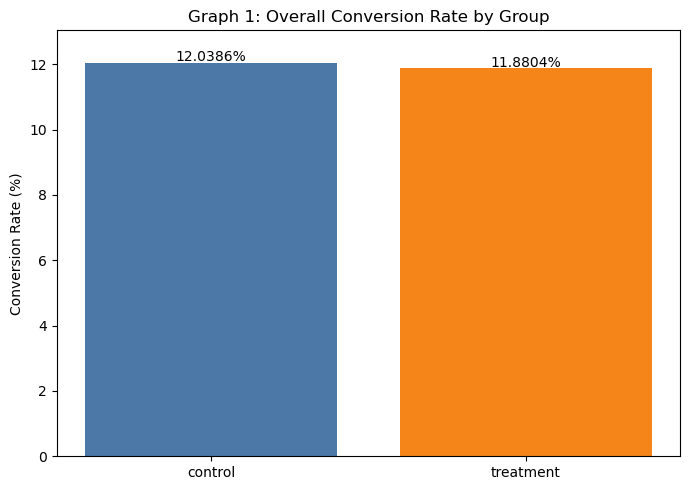

Graph 1 ready: Overall conversion rate by group.
Control   = 12.0386%
Treatment = 11.8804%


In [79]:
# STEP 28: GRAPH 1 - OVERALL CONVERSION RATE BY GROUP
summary = df.groupby('group')['converted'].mean().mul(100)
summary = summary.reindex(['control', 'treatment'])

plt.figure(figsize=(7, 5))
bars = plt.bar(summary.index, summary.values, color=['#4C78A8', '#F58518'])
plt.title('Graph 1: Overall Conversion Rate by Group')
plt.ylabel('Conversion Rate (%)')
plt.ylim(0, max(summary.values) + 1)

for bar, val in zip(bars, summary.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.05, f'{val:.4f}%', ha='center')

plt.tight_layout()
plt.show()

print('Graph 1 ready: Overall conversion rate by group.')
print(f"Control   = {summary['control']:.4f}%")
print(f"Treatment = {summary['treatment']:.4f}%")

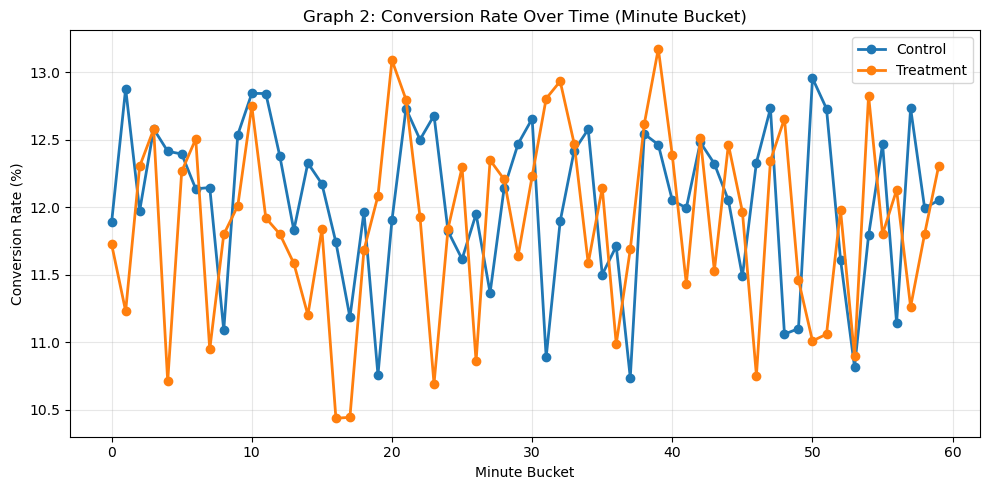

Graph 2 ready: Conversion rate over time by minute bucket.
This graph helps check whether treatment improves or worsens over time.


In [81]:
# Parse timestamp to seconds and build minute bucket

def parse_time(t):
    parts = str(t).split(':')
    return float(parts[0]) * 60 + float(parts[1])

df['time_seconds'] = df['timestamp'].apply(parse_time)
df['minute_bucket'] = (df['time_seconds'] // 60).astype(int)

# STEP 29: GRAPH 2 - CONVERSION RATE OVER TIME
minute_summary = df.groupby(['minute_bucket', 'group'])['converted'].mean().unstack().mul(100)
minute_summary = minute_summary.reindex(columns=['control', 'treatment'])

plt.figure(figsize=(10, 5))
plt.plot(minute_summary.index, minute_summary['control'], marker='o', linewidth=2, label='Control')
plt.plot(minute_summary.index, minute_summary['treatment'], marker='o', linewidth=2, label='Treatment')
plt.title('Graph 2: Conversion Rate Over Time (Minute Bucket)')
plt.xlabel('Minute Bucket')
plt.ylabel('Conversion Rate (%)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Graph 2 ready: Conversion rate over time by minute bucket.')
print('This graph helps check whether treatment improves or worsens over time.')

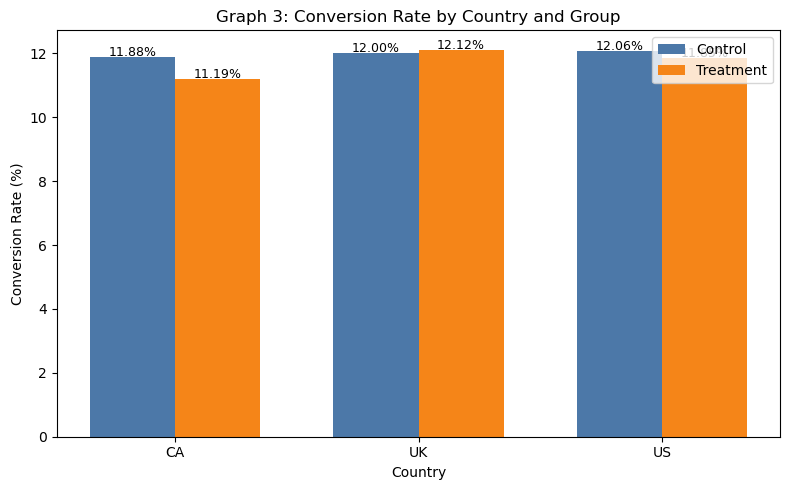

Graph 3 ready: Conversion rate by country and group.
UK is the only country with a small positive directional lift, but it is not statistically significant.


In [83]:
# STEP 30: GRAPH 3 - CONVERSION RATE BY COUNTRY AND GROUP
country_summary = df.groupby(['country', 'group'])['converted'].mean().unstack().mul(100)
country_summary = country_summary.reindex(index=['CA', 'UK', 'US'], columns=['control', 'treatment'])

x = np.arange(len(country_summary.index))
width = 0.35

plt.figure(figsize=(8, 5))
bar1 = plt.bar(x - width/2, country_summary['control'], width, label='Control', color='#4C78A8')
bar2 = plt.bar(x + width/2, country_summary['treatment'], width, label='Treatment', color='#F58518')

plt.title('Graph 3: Conversion Rate by Country and Group')
plt.xlabel('Country')
plt.ylabel('Conversion Rate (%)')
plt.xticks(x, country_summary.index)
plt.legend()

for bars in [bar1, bar2]:
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h + 0.03, f'{h:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print('Graph 3 ready: Conversion rate by country and group.')
print('UK is the only country with a small positive directional lift, but it is not statistically significant.')